# 🎯 Notebook 02: Smart Priors from Data

**The biggest challenge in Bayesian MMM isn't the model — it's choosing good priors.** Bad priors lead to unrealistic coefficients, negative contributions, and results nobody trusts.

This notebook shows you how to **automatically generate informed priors** from your data, using the same principles that production MMM platforms use.

### What you'll learn:

1. **Why priors matter** — visual comparison of uninformed vs. informed priors
2. **Automatic prior generation** — compute InverseGamma priors for media channels from data characteristics
3. **Constrained prior optimization** — find Beta/Gamma shapes that put probability mass where you need it
4. **Industry benchmarks** — starting points for FMCG, Retail, E-Commerce, and more

---

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats, optimize
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC', 'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE', 'axes.grid': True, 'grid.alpha': 0.3,
})
COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

df = pd.read_csv('data/sample_mmm_weekly.csv', parse_dates=['date'])
TARGET_COL = 'revenue'
MEDIA_COLS = ['tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend']
print(f'✅ Loaded {len(df)} rows, {len(MEDIA_COLS)} media channels')

✅ Loaded 104 rows, 5 media channels


---

## Why Priors Matter: A Visual Comparison

Let's see what happens when you use **flat priors** (no information) vs. **informed priors** (data-driven). The flat prior allows the model to assign a huge coefficient to a small channel, or even negative coefficients.

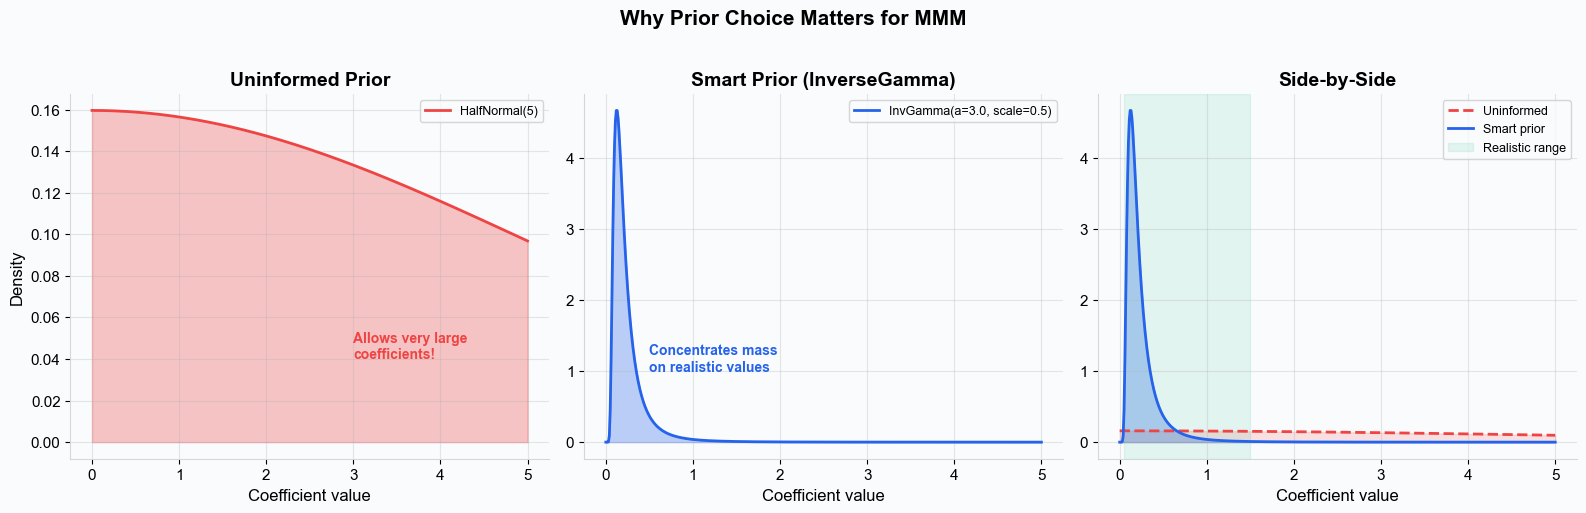


Informed priors keep coefficients in a realistic range while still letting data speak.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x = np.linspace(0, 5, 500)

# Flat / uninformed
ax = axes[0]
ax.fill_between(x, stats.halfnorm.pdf(x, scale=5), alpha=0.3, color=COLORS[3])
ax.plot(x, stats.halfnorm.pdf(x, scale=5), color=COLORS[3], linewidth=2, label='HalfNormal(5)')
ax.set_title('Uninformed Prior')
ax.set_xlabel('Coefficient value')
ax.set_ylabel('Density')
ax.annotate('Allows very large\ncoefficients!', xy=(3, 0.04), fontsize=10,
           color=COLORS[3], fontweight='bold')
ax.legend(fontsize=9)

# Weakly informed (InverseGamma)
ax = axes[1]
a, scale = 3.0, 0.5
ax.fill_between(x, stats.invgamma.pdf(x, a, scale=scale), alpha=0.3, color=COLORS[0])
ax.plot(x, stats.invgamma.pdf(x, a, scale=scale), color=COLORS[0], linewidth=2,
       label=f'InvGamma(a={a}, scale={scale})')
ax.set_title('Smart Prior (InverseGamma)')
ax.set_xlabel('Coefficient value')
ax.annotate('Concentrates mass\non realistic values', xy=(0.5, 1.0), fontsize=10,
           color=COLORS[0], fontweight='bold')
ax.legend(fontsize=9)

# Comparison overlay
ax = axes[2]
ax.fill_between(x, stats.halfnorm.pdf(x, scale=5), alpha=0.15, color=COLORS[3])
ax.plot(x, stats.halfnorm.pdf(x, scale=5), color=COLORS[3], linewidth=2, linestyle='--', label='Uninformed')
ax.fill_between(x, stats.invgamma.pdf(x, a, scale=scale), alpha=0.3, color=COLORS[0])
ax.plot(x, stats.invgamma.pdf(x, a, scale=scale), color=COLORS[0], linewidth=2, label='Smart prior')
ax.axvspan(0.05, 1.5, alpha=0.1, color=COLORS[2], label='Realistic range')
ax.set_title('Side-by-Side')
ax.set_xlabel('Coefficient value')
ax.legend(fontsize=9)

plt.suptitle('Why Prior Choice Matters for MMM', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/02_prior_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('\nInformed priors keep coefficients in a realistic range while still letting data speak.')

---

## Step 1: Channel Weight Analysis

The first input to smart priors is **how much each channel spends relative to the total**. High-spend channels typically get smaller per-dollar coefficients (they're working harder, so marginal returns are lower).

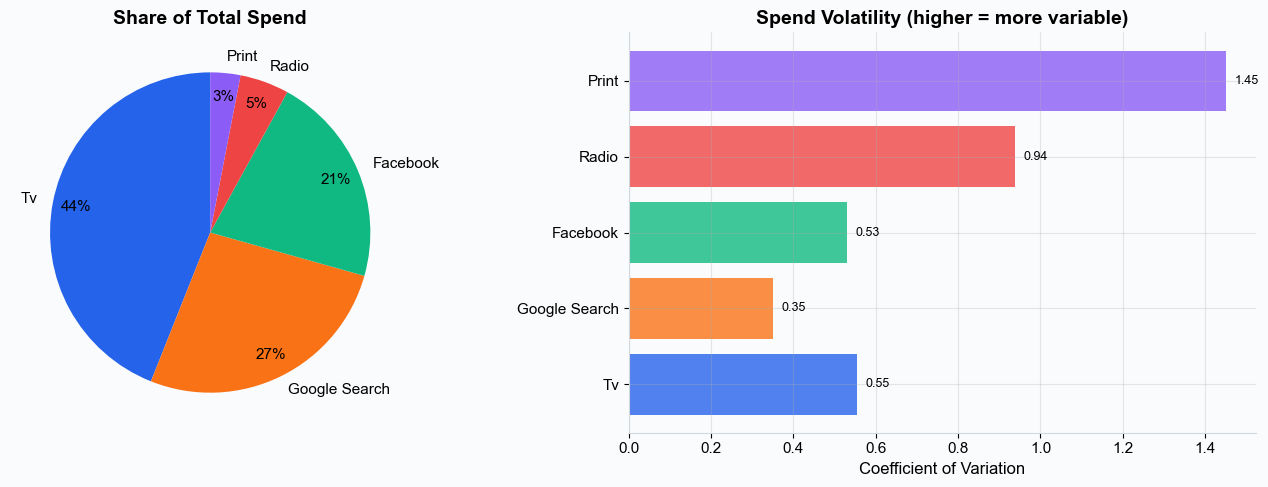

            channel  total_spend  spend_share       cv  nonzero_pct
           tv_spend   3319667.13     0.439682 0.554362    87.500000
google_search_spend   2013737.57     0.266715 0.350617   100.000000
     facebook_spend   1613207.59     0.213666 0.531077   100.000000
        radio_spend    374201.80     0.049562 0.939367    67.307692
        print_spend    229335.17     0.030375 1.451592    54.807692


In [3]:
# Compute channel statistics
channel_stats = pd.DataFrame({
    'channel': MEDIA_COLS,
    'total_spend': [df[col].sum() for col in MEDIA_COLS],
    'mean_spend': [df[col].mean() for col in MEDIA_COLS],
    'std_spend': [df[col].std() for col in MEDIA_COLS],
    'cv': [df[col].std() / (df[col].mean() + 1e-10) for col in MEDIA_COLS],
    'nonzero_pct': [(df[col] > 0).mean() * 100 for col in MEDIA_COLS],
})
channel_stats['spend_share'] = channel_stats['total_spend'] / channel_stats['total_spend'].sum()
channel_stats = channel_stats.sort_values('total_spend', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Spend shares
labels = [c.replace('_spend', '').replace('_', ' ').title() for c in channel_stats['channel']]
colors = [COLORS[i % len(COLORS)] for i in range(len(labels))]
ax1.pie(channel_stats['spend_share'], labels=labels, colors=colors, autopct='%1.0f%%',
       startangle=90, pctdistance=0.85)
ax1.set_title('Share of Total Spend')

# Coefficient of variation (how "spiky" is spend?)
ax2.barh(range(len(labels)), channel_stats['cv'].values, color=colors, alpha=0.8)
ax2.set_yticks(range(len(labels)))
ax2.set_yticklabels(labels)
ax2.set_xlabel('Coefficient of Variation')
ax2.set_title('Spend Volatility (higher = more variable)')
for i, v in enumerate(channel_stats['cv'].values):
    ax2.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/02_channel_analysis.png', dpi=180, bbox_inches='tight')
plt.show()

print(channel_stats[['channel', 'total_spend', 'spend_share', 'cv', 'nonzero_pct']].to_string(index=False))

---

## Step 2: Auto-Generate InverseGamma Priors for Media Coefficients

Production MMM platforms use **InverseGamma** as the default prior for media channel coefficients. Why?

- It's **strictly positive** (ad spend can't hurt revenue)
- It has a **heavy right tail** (allows for surprisingly effective channels)
- The shape is controlled by two parameters: `alpha` (shape) and `beta` (scale)

The logic: channels with **higher spend share** get **smaller priors** (diminishing returns already captured by saturation), while channels with **higher volatility** get **wider priors** (more uncertainty).

In [4]:
def generate_smart_priors(df, media_cols, target_col, industry='general'):
    """Generate InverseGamma priors for media coefficients based on data characteristics."""
    
    # Industry-specific elasticity targets
    industry_elasticity = {
        'fmcg': 0.10,
        'retail': 0.15,
        'ecommerce': 0.20,
        'financial': 0.08,
        'telco': 0.12,
        'general': 0.15,
    }
    target_elasticity = industry_elasticity.get(industry, 0.15)
    
    target_mean = df[target_col].mean()
    total_spend = sum(df[col].sum() for col in media_cols)
    priors = {}
    
    for col in media_cols:
        spend_mean = df[col].mean()
        spend_std = df[col].std()
        spend_share = df[col].sum() / total_spend
        cv = spend_std / (spend_mean + 1e-10)
        
        # Target coefficient: what coefficient would give the expected elasticity?
        # elasticity = beta * mean_spend / mean_revenue (approximately)
        target_coeff = target_elasticity * target_mean / (spend_mean + 1e-10) * spend_share
        
        # Dampening: high-spend channels get smaller coefficients
        dampen = 1 / (1 + spend_share * 5)
        target_coeff *= dampen
        
        # InverseGamma parameters
        # For InverseGamma(alpha, beta): mean = beta / (alpha - 1)
        # We want mean near target_coeff, with width proportional to CV
        ig_alpha = max(3.0, 5.0 - cv)  # More volatile -> less concentrated
        ig_beta = target_coeff * (ig_alpha - 1)
        
        priors[col] = {
            'distribution': 'InverseGamma',
            'alpha': round(ig_alpha, 2),
            'beta': round(ig_beta, 4),
            'prior_mean': round(ig_beta / (ig_alpha - 1), 4),
            'target_elasticity': round(target_elasticity * spend_share * dampen, 4),
            'spend_share': round(spend_share, 3),
        }
    
    return priors

priors = generate_smart_priors(df, MEDIA_COLS, TARGET_COL, industry='retail')

# Display
prior_df = pd.DataFrame(priors).T
print('Generated Smart Priors:\n')
print(prior_df.to_string())

Generated Smart Priors:

                     distribution alpha    beta prior_mean target_elasticity spend_share
tv_spend             InverseGamma  4.45  0.9837     0.2855            0.0206        0.44
facebook_spend       InverseGamma  4.47  1.5314     0.4415            0.0155       0.214
google_search_spend  InverseGamma  4.65  1.4279     0.3913            0.0171       0.267
radio_spend          InverseGamma  4.06  2.2396     0.7318             0.006        0.05
print_spend          InverseGamma  3.55  2.0201     0.7927             0.004        0.03


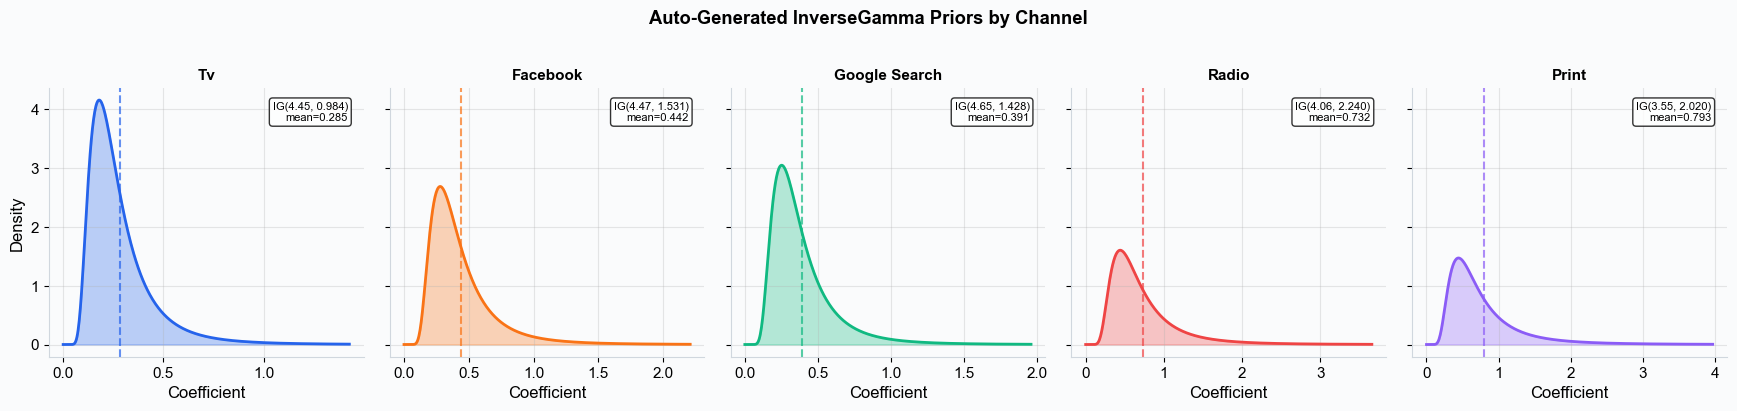


Each channel gets a different prior based on its spend share and volatility.


In [5]:
# Visualize the generated priors
fig, axes = plt.subplots(1, len(MEDIA_COLS), figsize=(3.5 * len(MEDIA_COLS), 4), sharey=True)

for i, col in enumerate(MEDIA_COLS):
    ax = axes[i]
    p = priors[col]
    x = np.linspace(0.001, p['prior_mean'] * 5, 500)
    y = stats.invgamma.pdf(x, p['alpha'], scale=p['beta'])
    
    ax.fill_between(x, y, alpha=0.3, color=COLORS[i % len(COLORS)])
    ax.plot(x, y, color=COLORS[i % len(COLORS)], linewidth=2)
    ax.axvline(x=p['prior_mean'], color=COLORS[i % len(COLORS)], linestyle='--', alpha=0.7)
    ax.set_title(col.replace('_spend', '').replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Coefficient')
    ax.text(0.95, 0.95, f"IG({p['alpha']}, {p['beta']:.3f})\nmean={p['prior_mean']:.3f}",
           transform=ax.transAxes, ha='right', va='top', fontsize=8,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Density')
plt.suptitle('Auto-Generated InverseGamma Priors by Channel', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/02_smart_priors.png', dpi=180, bbox_inches='tight')
plt.show()
print('\nEach channel gets a different prior based on its spend share and volatility.')

---

## Step 3: Constrained Prior Optimization

Sometimes you need a prior that puts a **specific probability mass** within a range. For example:

> *"I want 80% probability that the decay rate is between 0.3 and 0.9"*

We can **optimize** Beta distribution parameters to achieve this. This is what production platforms do behind the scenes when you set bounds in the UI.

Example: Finding Beta prior for adstock decay rates



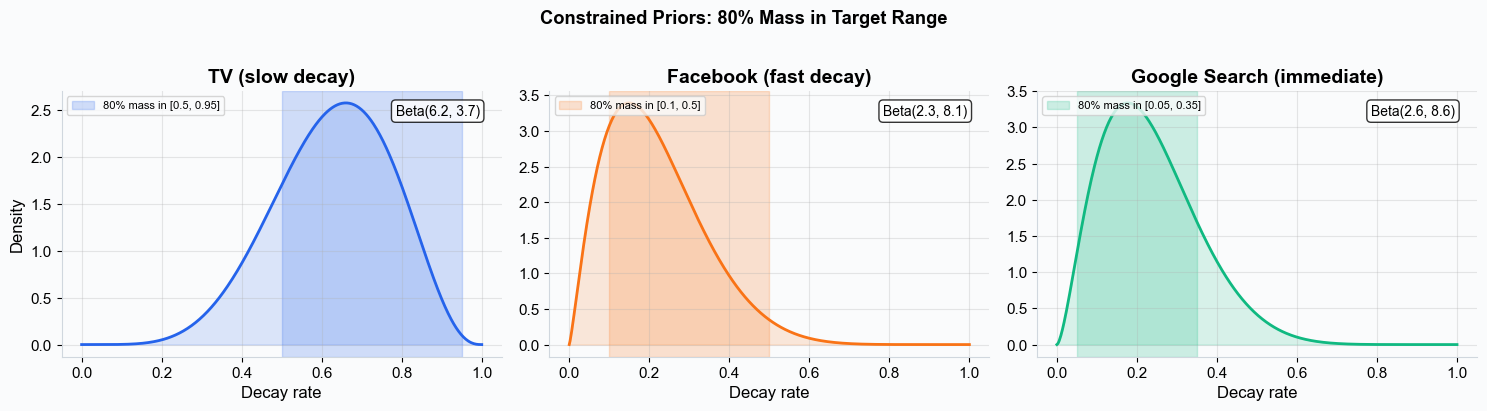


The optimizer finds Beta parameters that concentrate probability where you expect the true value to be.


In [6]:
def find_constrained_prior(target_mass, lower, upper, distribution='beta'):
    """Find distribution parameters that put target_mass probability between lower and upper."""
    
    def objective(params):
        if distribution == 'beta':
            a, b = params
            if a <= 0 or b <= 0:
                return 1e6
            mass = stats.beta.cdf(upper, a, b) - stats.beta.cdf(lower, a, b)
        elif distribution == 'gamma':
            a, scale = params
            if a <= 0 or scale <= 0:
                return 1e6
            mass = stats.gamma.cdf(upper, a, scale=scale) - stats.gamma.cdf(lower, a, scale=scale)
        return (mass - target_mass) ** 2
    
    # Try multiple starting points
    best_result = None
    best_loss = 1e6
    for a0 in [1.0, 2.0, 5.0, 10.0]:
        for b0 in [1.0, 2.0, 5.0, 10.0]:
            try:
                result = optimize.minimize(objective, [a0, b0], method='Nelder-Mead',
                                         options={'maxiter': 5000})
                if result.fun < best_loss:
                    best_loss = result.fun
                    best_result = result
            except:
                pass
    
    return best_result.x

# Example: Decay rate priors
print('Example: Finding Beta prior for adstock decay rates\n')

constraints = [
    ('TV (slow decay)', 0.80, 0.5, 0.95),
    ('Facebook (fast decay)', 0.80, 0.1, 0.5),
    ('Google Search (immediate)', 0.80, 0.05, 0.35),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.linspace(0, 1, 500)

for i, (name, mass, low, high) in enumerate(constraints):
    a, b = find_constrained_prior(mass, low, high, 'beta')
    y = stats.beta.pdf(x, a, b)
    actual_mass = stats.beta.cdf(high, a, b) - stats.beta.cdf(low, a, b)
    
    ax = axes[i]
    ax.fill_between(x, y, alpha=0.15, color=COLORS[i])
    ax.plot(x, y, color=COLORS[i], linewidth=2)
    ax.axvspan(low, high, alpha=0.2, color=COLORS[i], label=f'{actual_mass:.0%} mass in [{low}, {high}]')
    ax.set_title(name)
    ax.set_xlabel('Decay rate')
    ax.text(0.95, 0.95, f'Beta({a:.1f}, {b:.1f})', transform=ax.transAxes,
           ha='right', va='top', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(fontsize=8, loc='upper left')

axes[0].set_ylabel('Density')
plt.suptitle('Constrained Priors: 80% Mass in Target Range', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/02_constrained_priors.png', dpi=180, bbox_inches='tight')
plt.show()

print('\nThe optimizer finds Beta parameters that concentrate probability where you expect the true value to be.')

---

## Step 4: Saturation Parameter Priors

The saturation function `tanh(x / (scalar * alpha))` has a key parameter **alpha**. Production platforms typically use a **Gamma prior with mu=1.7** for alpha, which centers the curve at a reasonable diminishing-returns shape.

Let's visualize how different alpha values change the saturation curve.

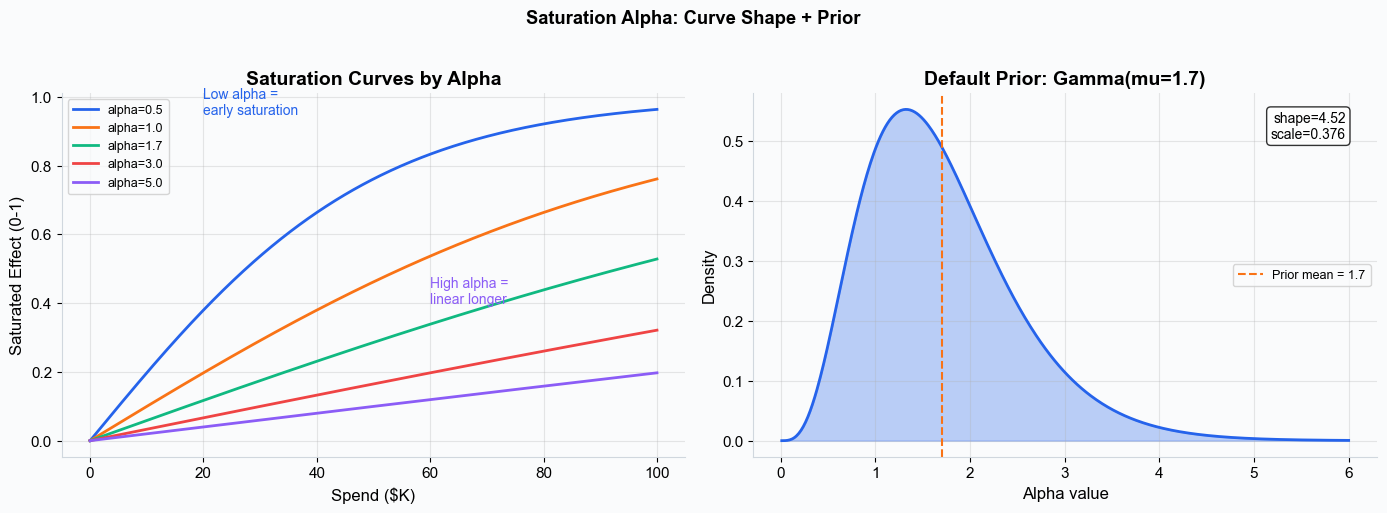

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Saturation curves for different alpha values
spend = np.linspace(0, 100000, 500)
scalar = 100000  # max spend

for i, alpha in enumerate([0.5, 1.0, 1.7, 3.0, 5.0]):
    saturated = np.tanh(spend / (scalar * alpha))
    ax1.plot(spend / 1000, saturated, color=COLORS[i % len(COLORS)], linewidth=2,
            label=f'alpha={alpha}')

ax1.set_xlabel('Spend ($K)')
ax1.set_ylabel('Saturated Effect (0-1)')
ax1.set_title('Saturation Curves by Alpha')
ax1.legend(fontsize=9)
ax1.annotate('Low alpha = \nearly saturation', xy=(20, 0.95), fontsize=10, color=COLORS[0])
ax1.annotate('High alpha = \nlinear longer', xy=(60, 0.4), fontsize=10, color=COLORS[4])

# Gamma prior for alpha (mu=1.7)
mu_alpha = 1.7
sigma_alpha = 0.8
# Gamma: shape = (mu/sigma)^2, scale = sigma^2/mu
shape = (mu_alpha / sigma_alpha) ** 2
scale = sigma_alpha ** 2 / mu_alpha
x = np.linspace(0.01, 6, 500)
y = stats.gamma.pdf(x, shape, scale=scale)

ax2.fill_between(x, y, alpha=0.3, color=COLORS[0])
ax2.plot(x, y, color=COLORS[0], linewidth=2)
ax2.axvline(x=mu_alpha, color=COLORS[1], linestyle='--', label=f'Prior mean = {mu_alpha}')
ax2.set_xlabel('Alpha value')
ax2.set_ylabel('Density')
ax2.set_title('Default Prior: Gamma(mu=1.7)')
ax2.legend(fontsize=9)
ax2.text(0.95, 0.95, f'shape={shape:.2f}\nscale={scale:.3f}',
        transform=ax2.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Saturation Alpha: Curve Shape + Prior', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/02_saturation_prior.png', dpi=180, bbox_inches='tight')
plt.show()

---

## Step 5: Industry Benchmark Reference

When you have no domain knowledge at all, industry benchmarks provide a starting point. These are approximate elasticity targets that can seed your prior generation.

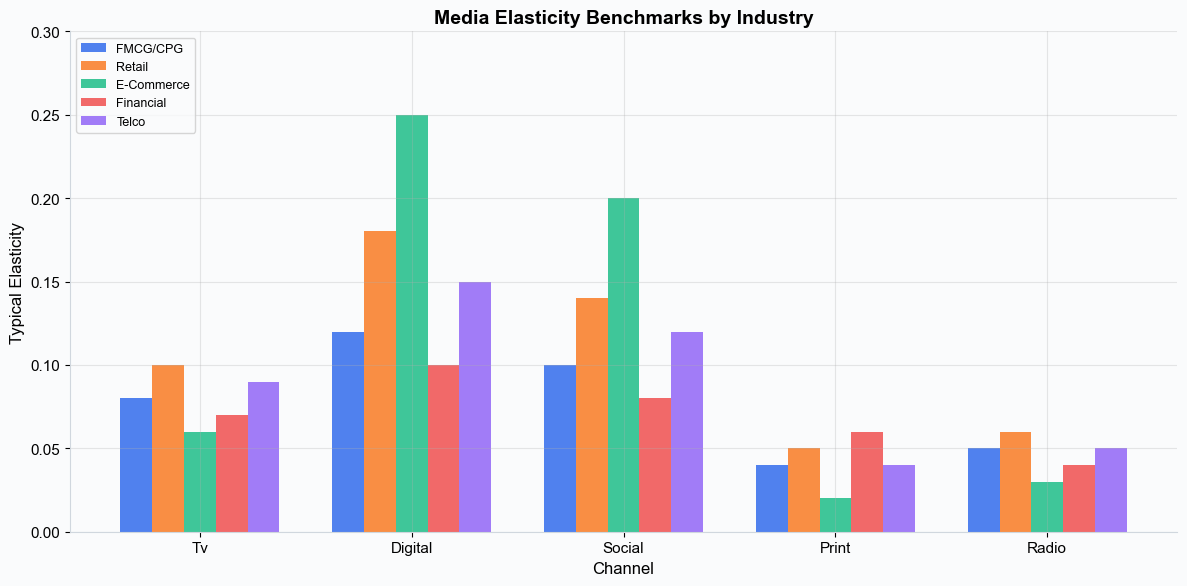

These are starting points — your model will learn the true values from data.
Use these to sanity-check your posteriors: if your model says TV elasticity is 0.5 in FMCG, something is wrong.


In [8]:
# Industry benchmarks for media elasticities
benchmarks = {
    'FMCG/CPG': {'tv': 0.08, 'digital': 0.12, 'social': 0.10, 'print': 0.04, 'radio': 0.05},
    'Retail': {'tv': 0.10, 'digital': 0.18, 'social': 0.14, 'print': 0.05, 'radio': 0.06},
    'E-Commerce': {'tv': 0.06, 'digital': 0.25, 'social': 0.20, 'print': 0.02, 'radio': 0.03},
    'Financial': {'tv': 0.07, 'digital': 0.10, 'social': 0.08, 'print': 0.06, 'radio': 0.04},
    'Telco': {'tv': 0.09, 'digital': 0.15, 'social': 0.12, 'print': 0.04, 'radio': 0.05},
}

fig, ax = plt.subplots(figsize=(12, 6))
channels = ['tv', 'digital', 'social', 'print', 'radio']
x = np.arange(len(channels))
width = 0.15

for i, (industry, elasticities) in enumerate(benchmarks.items()):
    values = [elasticities[ch] for ch in channels]
    ax.bar(x + i * width, values, width, label=industry, color=COLORS[i], alpha=0.8)

ax.set_xlabel('Channel')
ax.set_ylabel('Typical Elasticity')
ax.set_title('Media Elasticity Benchmarks by Industry')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([ch.title() for ch in channels])
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(0, 0.30)

plt.tight_layout()
plt.savefig('images/02_industry_benchmarks.png', dpi=180, bbox_inches='tight')
plt.show()

print('These are starting points — your model will learn the true values from data.')
print('Use these to sanity-check your posteriors: if your model says TV elasticity is 0.5 in FMCG, something is wrong.')

---

## Step 6: Using Smart Priors with PyMC-Marketing

Here's how to apply these priors in an actual PyMC-Marketing model:

In [9]:
# Generate the priors dictionary
smart_priors = generate_smart_priors(df, MEDIA_COLS, TARGET_COL, industry='retail')

print('PyMC-Marketing Prior Configuration:')
print('=' * 50)
print()
print('import pymc as pm')
print('from pymc_marketing.mmm import MMM')
print()
print('# --- Auto-generated priors ---')
for col, p in smart_priors.items():
    channel_name = col.replace('_spend', '')
    print(f'# {channel_name}: spend_share={p["spend_share"]:.1%}, prior_mean={p["prior_mean"]:.4f}')

print()
print('# Decay priors (geometric adstock)')
print('# TV: slow decay (long-lasting effect)')
print('# Digital: fast decay (immediate effect)')
decay_configs = {
    'tv': (0.5, 0.95),
    'facebook': (0.1, 0.5),
    'google_search': (0.05, 0.35),
    'radio': (0.3, 0.7),
    'print': (0.4, 0.8),
}

print('\n# Saturation alpha prior')
print(f'# Gamma(mu=1.7, sigma=0.8) -> shape={shape:.2f}, scale={scale:.3f}')
print()
print('✅ Copy these into your PyMC-Marketing model configuration!')

PyMC-Marketing Prior Configuration:

import pymc as pm
from pymc_marketing.mmm import MMM

# --- Auto-generated priors ---
# tv: spend_share=44.0%, prior_mean=0.2855
# facebook: spend_share=21.4%, prior_mean=0.4415
# google_search: spend_share=26.7%, prior_mean=0.3913
# radio: spend_share=5.0%, prior_mean=0.7318
# print: spend_share=3.0%, prior_mean=0.7927

# Decay priors (geometric adstock)
# TV: slow decay (long-lasting effect)
# Digital: fast decay (immediate effect)

# Saturation alpha prior
# Gamma(mu=1.7, sigma=0.8) -> shape=4.52, scale=0.376

✅ Copy these into your PyMC-Marketing model configuration!


---

## Summary: The Smart Priors Workflow

1. **Analyze channel statistics** — spend share, volatility, coverage
2. **Set industry baselines** — target elasticities by vertical
3. **Generate InverseGamma priors** — scale by spend share, widen by volatility
4. **Constrain decay/saturation priors** — optimize Beta/Gamma to hit target ranges
5. **Validate against benchmarks** — posteriors should be in the right ballpark

## Next Steps

- **[Notebook 08: Tanh Saturation](08-tanh-saturation-deep-dive.ipynb)** — Deep dive into the saturation function
- **[Notebook 05: Delayed Adstock](05-delayed-adstock.ipynb)** — Priors for channels with delayed effects
- **[Notebook 10: Lift Test Calibration](10-lift-test-calibration.ipynb)** — Update priors with incrementality evidence

**Core concepts:**
- [Priors and Distributions](../docs/core-concepts/priors-and-distributions.md)
- [Bayesian Modeling](../docs/core-concepts/bayesian-modeling.md)
- [Saturation Curves](../docs/core-concepts/saturation-curves.md)